In [31]:
### Compute Constraint ###

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Function to process the file and extract columns
def read_and_process_file(file_path):
    with open(file_path, 'r') as f:
        # Read the entire file and split into lines
        lines = f.readlines()
    
    # Convert each line to a list of floats (each line is a row)
    data = [list(map(float, line.split())) for line in lines]
    
    # Transpose to columns
    return list(zip(*data))  # Each column is now a list

# Function to read blocks from the data file
def read_blocks(file_path):
    with open(file_path, 'r') as f:
        blocks = f.read().strip().split("\n\n")
    return [block.strip() for block in blocks]

# Function to read the times from the time file
def read_times(time_file_path):
    with open(time_file_path, 'r') as f:
        times = [float(line.strip()) for line in f.readlines()]
    return times

# Function to process a block into columns (x, y1, y2, y3)
def process_block(block):
    data = [list(map(float, line.split())) for line in block.split("\n")]
    return list(zip(*data))  # Transpose to columns

path = '../CLOutput/pbh/'
analytic = '../Analytics/pbh_CL/'
M_p = 2.435e18
f_star = M_p
omega_star =  M_p


# Read and process the data
avg_scalar = read_and_process_file(path + 'average_scalar_0.txt')
avg_sf = read_and_process_file(path + 'average_scale_factor.txt')
avg_energies = read_and_process_file(path + 'average_energies.txt')
avg_energies_conservation = read_and_process_file(path + 'average_energy_conservation.txt')
spectra_blocks = read_blocks(path + 'spectra_scalar_0.txt')
spectra_times = read_times(path + 'average_spectra_times.txt')

# Read scale factors and times then create interpolation
t = np.array(avg_sf[0])
a = np.array(avg_sf[1])
a_t = UnivariateSpline(t, a, s=0) # I use _t to denote, 'as a function of t'

# Read the Hubble then create interpolation
Hubble = np.array(avg_sf[3]) * omega_star/M_p
Hubble_t = UnivariateSpline(t,Hubble,s=0)

# Define horizon wavevector then create interpolation
kh = Hubble * a 
kh_t = UnivariateSpline(t, kh, s=0)

# Read field velocity and times then create interpolation
phi = np.array(avg_scalar[1]) * f_star/M_p
phi_t = UnivariateSpline(t,phi,s=0)
dphi = np.array(avg_scalar[2]) * f_star * omega_star / M_p**2 # Time derivative is w.r.t. cosmic time
dphi_t = UnivariateSpline(t,dphi,s=0)
ddphi_t = dphi_t.derivative()
V = np.array(avg_energies[3]) * (f_star * omega_star)**2 / M_p**4
V_t = UnivariateSpline(t,V,s=0)
dV_t = UnivariateSpline(t,V,s=0).derivative

# Define epsilon
def epsilon_t(t):
    return 0.5 * dphi_t(t)**2 / (Hubble_t(t)**2)

ddphi_t_calc = dphi_t.derivative()

def ddphi_t(t):
    return ddphi_t_calc(t)  * omega_star / M_p

def eta_t(t):
    return -ddphi_t(t) / (Hubble_t(t) * dphi_t(t))


# Indices of the spectra blocks to plot
indices_to_plot = [i for i in range(0, int(len(spectra_blocks)/10), 1)] # Divide by 10 to only print first 20% of evolution

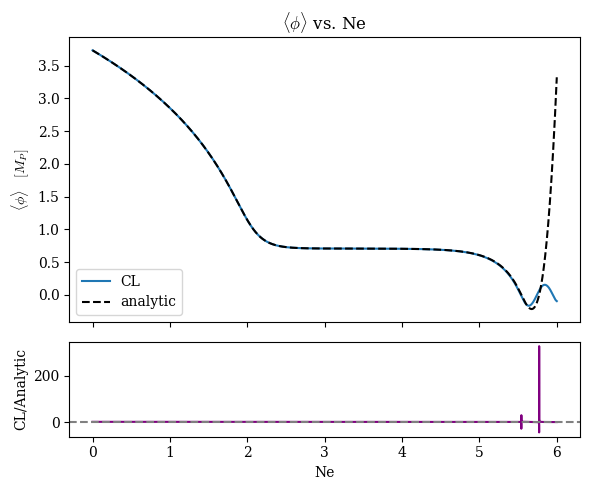

In [32]:
# Interpolate chi onto log(a) = Ne to match phi's domain
data = np.loadtxt(analytic+"phi_vs_Ne.txt")
Ne = data[:, 0]
chi = data[:, 1]
chi_interp = UnivariateSpline(Ne, chi,s=0)
chi_on_phi_domain = chi_interp(np.log(a))

plot_lim = 6
# Compute the ratio
ratio = phi / chi_on_phi_domain
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(6, 5), gridspec_kw={'height_ratios': [3, 1]})
mask = (a >= np.exp(0)) & (a <= np.exp(plot_lim))

# use the mask on y arrays
phi2 = phi[mask]
chi_on_phi_domain2 = chi_on_phi_domain[mask]
a2 = a[mask]
ratio2 = ratio[mask]

# Top plot: main comparison
ax1.plot(np.log(a2), phi2, label='CL')
ax1.plot(np.log(a2), chi_on_phi_domain2, label='analytic', color='black', linestyle='--')
ax1.set_ylabel(r'$\langle\phi\rangle\quad [M_P]$')
ax1.set_title(r'$\langle\phi\rangle$ vs. Ne')
ax1.legend()

# Bottom plot: ratio
ax2.plot(np.log(a2), ratio2, label='CL / analytic', color='purple')
ax2.axhline(1.0, color='gray', linestyle='--')
ax2.set_xlabel(r'Ne')
ax2.set_ylabel('CL/Analytic')
plt.tight_layout()
plt.show()


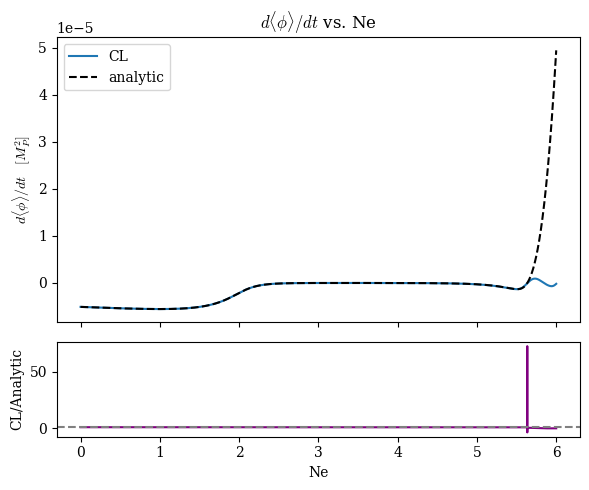

In [33]:
# Interpolate chi onto log(a) = Ne to match phi's domain
data = np.loadtxt(analytic + "dphidt_vs_Ne.txt")
Ne = data[:, 0]
dchi = data[:, 1]
dchi_interp = UnivariateSpline(Ne, dchi,s=0)
dchi_on_phi_domain = dchi_interp(np.log(a))

# Compute the ratio
ratio = (dphi) / dchi_on_phi_domain

mask = (a >= 0) & (a <= np.exp(plot_lim))

# use the mask on y arrays
dphi2 = dphi[mask]
dchi_on_phi_domain2 = dchi_on_phi_domain[mask]
a2 = a[mask]
ratio2 = ratio[mask]

# Create the figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(6, 5), gridspec_kw={'height_ratios': [3, 1]})

# Top plot: main comparison
ax1.plot(np.log(a2), dphi2, label='CL')
ax1.plot(np.log(a2), dchi_on_phi_domain2, label='analytic', color='black', linestyle='--')
ax1.set_ylabel(r'$d\langle\phi\rangle/dt\quad [M_P^2]$')
ax1.set_title(r'$d\langle\phi\rangle/dt $ vs. Ne')
ax1.legend()

# Bottom plot: ratio
ax2.plot(np.log(a2), ratio2, label='CL / analytic', color='purple')
ax2.axhline(1.0, color='gray', linestyle='--')
ax2.set_xlabel(r'Ne')
ax2.set_ylabel('CL/Analytic')

plt.tight_layout()

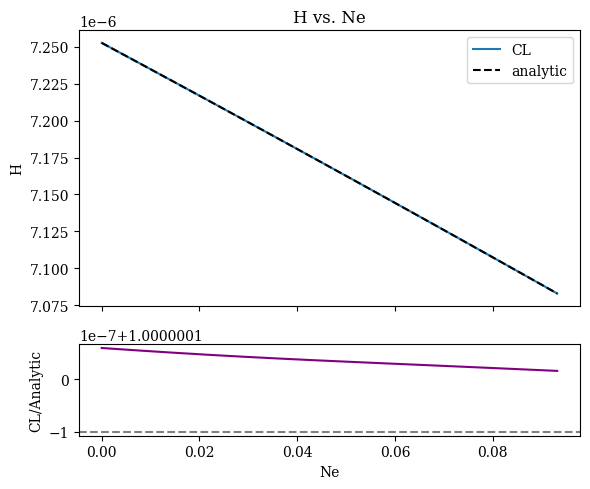

In [34]:
# Interpolate chi onto log(a) = Ne to match phi's domain
data = np.loadtxt(analytic+"H_vs_Ne.txt")
Ne = data[:, 0]
H = data[:, 1]
H_interp = UnivariateSpline(Ne, H,s=0)
H_on_H_domain = H_interp(np.log(a))

# Compute the ratio
ratio = (Hubble) / H_on_H_domain

# use the mask on y arrays
mask = (a >= 0) & (a <= np.exp(0.1))
Hubble2 = Hubble[mask]
H_on_H_domain2 = H_on_H_domain[mask]
a2 = a[mask]
ratio2 = ratio[mask]

# Create the figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(6, 5), gridspec_kw={'height_ratios': [3, 1]})

# Top plot: main comparison
ax1.plot(np.log(a2), Hubble2, label='CL')
ax1.plot(np.log(a2), H_on_H_domain2, label='analytic', color='black', linestyle='--')
ax1.set_ylabel(r'H')
ax1.set_title(r'H vs. Ne')
ax1.legend()

# Bottom plot: ratio
ax2.plot(np.log(a2), ratio2, label='CL / analytic', color='purple')
ax2.axhline(1.0, color='gray', linestyle='--')
ax2.set_xlabel(r'Ne')
ax2.set_ylabel('CL/Analytic')

plt.tight_layout()
plt.show()

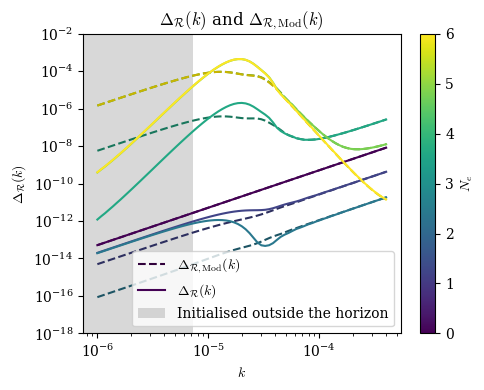

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import matplotlib.colors as mc
import colorsys

import matplotlib
#matplotlib.use("Agg")
matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['font.family'] = 'serif'

Mp = 2.435e18

# -----------------------------
# File locations
# -----------------------------
files_nonmod = sorted(glob.glob("../Analytics/pbh_CL/PS_modified_Nf=*.txt"))
files_mod = sorted(glob.glob("../Analytics/pbh_CL/PS_Nf=*.txt"))

# Extract all available Nf values
def extract_Nf(filename):
    return int(filename.split("Nf=")[-1].split(".txt")[0])

Nf_values = sorted(
    list(set([extract_Nf(f) for f in files_nonmod + files_mod]))
)

# Create consistent colour map
cmap = plt.cm.viridis
colors = {Nf: cmap(i / (len(Nf_values)-1 if len(Nf_values)>1 else 1))
          for i, Nf in enumerate(Nf_values)}

# Function to darker a matplotlib colour
def darken_color(color, amount=0.6):
    c = mc.to_rgb(color)
    h, l, s = colorsys.rgb_to_hls(*c)
    l = max(0, min(1, l * amount))
    return colorsys.hls_to_rgb(h, l, s)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=[5, 4])

# ---- Modified spectra (dashed) ----
for file in files_mod:
    data = np.loadtxt(file)
    k = data[:, 0]
    P = data[:, 1]

    Nf = extract_Nf(file)
    plt.plot(
        k / Mp,
        P,
        linestyle="--",
        color=darken_color(colors[Nf],0.7),
        label=rf'$\Delta_{{\mathcal{{R}},\mathrm{{Mod}}}}(k)$' if Nf == 0 else None
    )

# ---- Non-modified spectra (solid) ----

for file in files_nonmod:
    data = np.loadtxt(file)
    k = data[:, 0]
    P = data[:, 1]

    Nf = extract_Nf(file)

    plt.plot(
        k / Mp,
        P,
        linestyle="-",
        color=colors[Nf],
        label=rf'$\Delta_{{\mathcal{{R}}}}(k)$' if Nf == 0 else None
    )

target_Ne = [0, 1, 2, 3, 4, 5]

snapshot_indices = []
for target in target_Ne:
    # Calculate Ne for all available spectra times
    current_Nes = np.array([np.log(a_t(t)) for t in spectra_times])
    # Find index of the minimum difference
    idx = (np.abs(current_Nes - target)).argmin()
    snapshot_indices.append(idx)


for idx in snapshot_indices:
    block = spectra_blocks[idx]
    x, y1, y2, y3 = process_block(block)
    
    # Physics scaling from your first script
    k = np.array(x) * omega_star
    time = spectra_times[idx]
    current_ne = np.log(a_t(time))
    
    # Curvature perturbation calculation
    DeltaR = (np.array(y1)) * f_star**2 / (2 * epsilon_t(time) * M_p**4)
    
    ne_int = int(round(current_ne))   # or int(np.rint(current_ne))
    ne_int = max(min(ne_int, max(Nf_values)), min(Nf_values))  # clamp


# -----------------------------
# Styling
# -----------------------------
snap_cmap = cm.viridis
snap_norm = mcolors.Normalize(vmin=0, vmax=6)
sm = cm.ScalarMappable(cmap=snap_cmap, norm=snap_norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label(r'$N_e$')


plt.title(r'$\Delta_{\mathcal{R}}(k)$ and $\Delta_{\mathcal{R},\mathrm{Mod}}(k)$')
plt.xlabel(r'$k$')
plt.ylabel(r'$\Delta_\mathcal{R}(k)$')
plt.axvspan(kh_t(0)-1, kh_t(0), facecolor='grey', alpha=.3, label="Initialised outside the horizon")
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-18, 1e-2)
plt.legend()
plt.tight_layout()
plt.show()

/var/folders/q5/8ww_g3zn3834rzv85hpqm6k00000gp/T/ipykernel_8949/3412333119.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.87, 1.02])


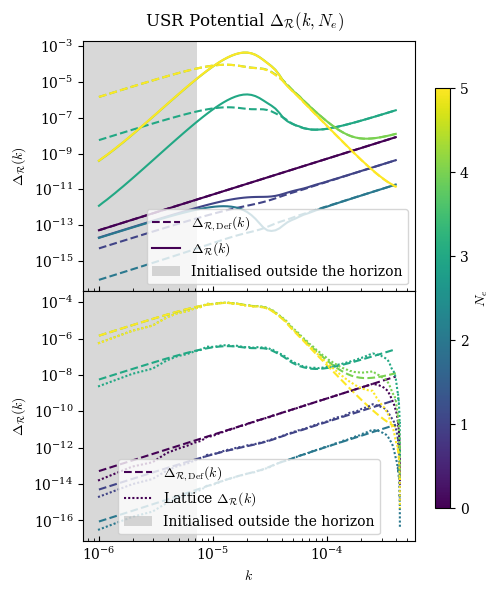

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mc
import matplotlib.cm as cm
import colorsys
import glob

# Constants
Mp = 2.435e18

# -----------------------------
# Data Preparation
# -----------------------------
files_nonmod = sorted(glob.glob("../Analytics/pbh_CL/PS_modified_Nf=*.txt"))
files_mod = sorted(glob.glob("../Analytics/pbh_CL/PS_Nf=*.txt"))

def extract_Nf(filename):
    return int(filename.split("Nf=")[-1].split(".txt")[0])

Nf_values = sorted(list(set([extract_Nf(f) for f in files_nonmod + files_mod])))

# Unified Color Map
cmap = plt.cm.viridis
colors = {Nf: cmap(i / (len(Nf_values)-1 if len(Nf_values)>1 else 1))
          for i, Nf in enumerate(Nf_values)}

def darken_color(color, amount=0.6):
    c = mc.to_rgb(color)
    h, l, s = colorsys.rgb_to_hls(*c)
    l = max(0, min(1, l * amount))
    return colorsys.hls_to_rgb(h, l, s)

# -----------------------------
# Plotting
# -----------------------------
# sharex=True aligns the k-axis, gridspec_kw={'hspace': 0} removes the gap
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 6), sharex=True, gridspec_kw={'hspace': 0})

# Helper for standard file plotting
def plot_files(ax, files, linestyle, is_mod=False, alpha=1.0):
    for file in files:
        data = np.loadtxt(file)
        k, P = data[:, 0], data[:, 1]
        Nf = extract_Nf(file)
        
        color = darken_color(colors[Nf], 1) if is_mod else colors[Nf]
        suffix = r",\text{Def}" if is_mod else ""
        label = rf'$\Delta_{{\mathcal{{R}}{suffix}}}(k)$' if (Nf == min(Nf_values)) else None
        
        ax.plot(k / Mp, P, linestyle=linestyle, color=color, label=label, alpha=alpha)

# --- Top Plot: Modified vs Non-Modified ---
plot_files(ax1, files_mod, "--", is_mod=True)
plot_files(ax1, files_nonmod, "-")
ax1.set_ylabel(r'$\Delta_\mathcal{R}(k)$')
ax1.axvspan(kh_t(0)-1, kh_t(0), facecolor='grey', alpha=.3, label="Initialised outside the horizon")

# --- Bottom Plot: Lattice vs Modified ---
# Re-plot modified spectra on bottom plot for comparison
plot_files(ax2, files_mod, "--", is_mod=True)

target_Ne = [0, 1, 2, 3, 4, 5]
current_Nes = np.array([np.log(a_t(t)) for t in spectra_times])

for target in target_Ne:
    idx = (np.abs(current_Nes - target)).argmin()
    block = spectra_blocks[idx]
    x, y1, y2, y3 = process_block(block)
    
    k_lat = np.array(x) * omega_star
    time = spectra_times[idx]
    DeltaR = (np.array(y1)) * f_star**2 / (2 * epsilon_t(time) * M_p**2)
    
    ne_val = np.log(a_t(time))
    ne_int = int(max(min(round(ne_val), max(Nf_values)), min(Nf_values)))

    ax2.plot(k_lat/M_p, DeltaR, color=colors[ne_int],linestyle=(0, (1, 1)),
             label=r'Lattice $\Delta_{{\mathcal{{R}}}}(k)$' if target == target_Ne[0] else None)

ax2.set_ylabel(r'$\Delta_\mathcal{R}(k)$')
ax2.axvspan(kh_t(0)-1, kh_t(0), facecolor='grey', alpha=.3, label="Initialised outside the horizon")

# -----------------------------
# Global Styling
# -----------------------------
fig.suptitle(r'USR Potential $\Delta_{\mathcal{R}}(k,N_e)$')

for ax in [ax1, ax2]:
    ax.set_xscale('log')
    ax.set_yscale('log')
    #ax.set_ylim(2e-18, 1)
    ax.legend()

# Clean up axis labels since they are touching
ax1.label_outer() 
ax2.set_xlabel(r'$k$')

# Unified Colorbar
norm = mc.Normalize(vmin=min(Nf_values), vmax=max(Nf_values))
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
ax1.tick_params(axis='x', which='both', direction='in', labelbottom=False)
ax2.tick_params(axis='x', which='both', direction='in')

# Adjusting the colorbar to span both axes
fig.subplots_adjust()
cax = fig.add_axes([0.88, 0.15, 0.03, 0.7]) 
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label(r'$N_e$')
fig.tight_layout(rect=[0, 0, 0.87, 1.02])
plt.show()

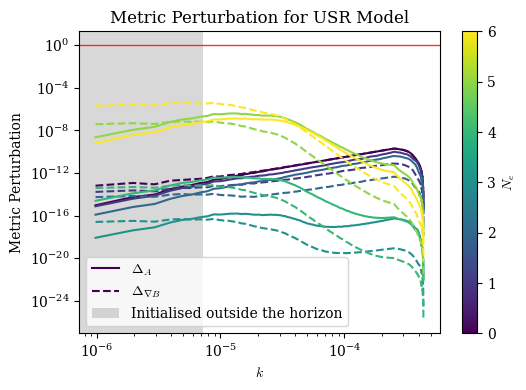

In [37]:
# Indices / targets in Ne
target_Ne = [0, 1, 2, 3, 4, 5, 6]
current_Nes = np.array([np.log(a_t(t)) for t in spectra_times])

# Output folder for the saved metric-perturbation data
out_dir = "pbh/"
os.makedirs(out_dir, exist_ok=True)

# Figure
fig, ax = plt.subplots(figsize=[5.5, 4])

# Color map by Ne
cmap = cm.viridis
norm = mcolors.Normalize(vmin=min(target_Ne), vmax=max(target_Ne))
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

for target in target_Ne:
    idx = np.abs(current_Nes - target).argmin()
    block = spectra_blocks[idx]
    x, y1, y2, y3 = process_block(block)

    # Use Mp consistently (you defined Mp above)
    k = np.array(x) * omega_star / Mp
    Deltaphi = np.array(y1) * f_star**2 / Mp**2
    Deltadphi = np.array(y2) * f_star**2 * omega_star**2 / Mp**4

    time = spectra_times[idx]
    eps = epsilon_t(time)
    H = Hubble_t(time)
    phidot = dphi_t(time)
    delta_sr = eta_t(time)


    DeltaA = (eps * H / phidot)**2 * Deltaphi
    DeltaB = (
        (eps * H / phidot)**2
        * (Deltadphi + (delta_sr - eps)**2 * H**2 * Deltaphi) / k**2
        
    )

    color = cmap(norm(target))
    ax.plot(k, DeltaA, color=color, linestyle='-',
            label=r'$\Delta_A$' if target == target_Ne[0] else None)
    ax.plot(k, DeltaB, color=color, linestyle='--',
            label=r'$\Delta_{\nabla B}$' if target == target_Ne[0] else None)

    # Save the data for this Ne snapshot
    save_data = np.column_stack([k, DeltaA, DeltaB])
    out_file = os.path.join(out_dir, f"MetricPerturbation_Ne{target}.txt")
    header = "k_over_Mp   abs_Ak   abs_kBk"
    np.savetxt(out_file, save_data, header=header)

ax.axvspan(kh_t(0) - 1, kh_t(0), facecolor='grey', alpha=.3,
           label="Initialised outside the horizon")

ax.set_xlabel(r'$k$')
ax.set_ylabel(r'Metric Perturbation')
ax.set_title("Metric Perturbation for USR Model")
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend()
ax.axhline(1, color='r', linestyle='-', linewidth=1, alpha=0.8)

cbar = plt.colorbar(sm, ax=ax)
cbar.set_label(r'$N_e$')

plt.tight_layout()
plt.show()

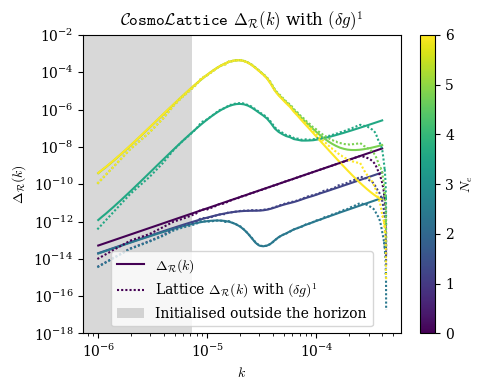

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import matplotlib.colors as mc
import colorsys

Mp = 2.435e18

# Values calculated in Mathematica notebook
path = '../ModifiedCLOutput/pbh/'
analytic = '../Analytics/pbh_CL/'
M_p = 2.435e18
f_star = M_p
omega_star =  M_p


# Read and process the data
avg_scalar = read_and_process_file(path + 'average_scalar_0.txt')
avg_sf = read_and_process_file(path + 'average_scale_factor.txt')
avg_energies = read_and_process_file(path + 'average_energies.txt')
avg_energies_conservation = read_and_process_file(path + 'average_energy_conservation.txt')
spectra_blocks = read_blocks(path + 'spectra_scalar_0.txt')
spectra_times = read_times(path + 'average_spectra_times.txt')

# Read scale factors and times then create interpolation
t = np.array(avg_sf[0])
a = np.array(avg_sf[1])
a_t = UnivariateSpline(t, a, s=0) # I use _t to denote, 'as a function of t'

# Read the Hubble then create interpolation
Hubble = np.array(avg_sf[3]) * omega_star/M_p
Hubble_t = UnivariateSpline(t,Hubble,s=0)

# Define horizon wavevector then create interpolation
kh = Hubble * a 
kh_t = UnivariateSpline(t, kh, s=0)

# Read field velocity and times then create interpolation
phi = np.array(avg_scalar[1]) * f_star/M_p
phi_t = UnivariateSpline(t,phi,s=0)
dphi = np.array(avg_scalar[2]) * f_star * omega_star / M_p**2 # Time derivative is w.r.t. cosmic time
dphi_t = UnivariateSpline(t,dphi,s=0)
ddphi_t = dphi_t.derivative()
V = np.array(avg_energies[3]) * (f_star * omega_star)**2 / M_p**4
V_t = UnivariateSpline(t,V,s=0)
dV_t = UnivariateSpline(t,V,s=0).derivative

# Define epsilon
def epsilon_t(t):
    return 0.5 * dphi_t(t)**2 / (Hubble_t(t)**2)

ddphi_t_calc = dphi_t.derivative()

def ddphi_t(t):
    return ddphi_t_calc(t)  * omega_star / M_p

def eta_t(t):
    return -ddphi_t(t) / (Hubble_t(t) * dphi_t(t))

# -----------------------------
# File locations
# -----------------------------
files_nonmod = sorted(glob.glob("../Analytics/pbh_CL/PS_modified_Nf=*.txt"))
files_mod = sorted(glob.glob("../Analytics/pbh_CL/PS_Nf=*.txt"))

# Extract all available Nf values
def extract_Nf(filename):
    return int(filename.split("Nf=")[-1].split(".txt")[0])

Nf_values = sorted(
    list(set([extract_Nf(f) for f in files_nonmod + files_mod]))
)

# Create consistent colour map
cmap = plt.cm.viridis
colors = {Nf: cmap(i / (len(Nf_values)-1 if len(Nf_values)>1 else 1))
          for i, Nf in enumerate(Nf_values)}

# Function to darker a matplotlib colour
def darken_color(color, amount=0.6):
    c = mc.to_rgb(color)
    h, l, s = colorsys.rgb_to_hls(*c)
    l = max(0, min(1, l * amount))
    return colorsys.hls_to_rgb(h, l, s)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=[5, 4])

# ---- Non-modified spectra (solid) ----
for file in files_nonmod:
    data = np.loadtxt(file)
    k = data[:, 0]
    P = data[:, 1]

    Nf = extract_Nf(file)

    plt.plot(
        k / Mp,
        P,
        linestyle="-",
        color=colors[Nf],
        label=rf'$\Delta_{{\mathcal{{R}}}}(k)$' if Nf == 0 else None
    )

target_Ne = [0, 1, 2, 3, 4, 5]

snapshot_indices = []
for target in target_Ne:
    # Calculate Ne for all available spectra times
    current_Nes = np.array([np.log(a_t(t)) for t in spectra_times])
    # Find index of the minimum difference
    idx = (np.abs(current_Nes - target)).argmin()
    snapshot_indices.append(idx)


for idx in snapshot_indices:
    block = spectra_blocks[idx]
    x, y1, y2, y3 = process_block(block)
    
    # Physics scaling from your first script
    k = np.array(x) * omega_star
    time = spectra_times[idx]
    current_ne = np.log(a_t(time))
    
    # Curvature perturbation calculation
    DeltaR = (np.array(y1)) * f_star**2 / (2 * epsilon_t(time) * M_p**2)
    
    ne_int = int(round(current_ne))   # or int(np.rint(current_ne))
    ne_int = max(min(ne_int, max(Nf_values)), min(Nf_values))  # clamp

    plt.plot(k/M_p, DeltaR,
         color=colors[ne_int],linestyle=(0, (1, 1)),
             label=r'Lattice $\Delta_{{\mathcal{{R}}}}(k)$ with $(\delta g)^1$' if idx == snapshot_indices[0] else None)


# -----------------------------
# Styling
# -----------------------------
sm = cm.ScalarMappable(cmap=snap_cmap, norm=snap_norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label(r'$N_e$')


plt.title(r'$\mathcal{C}\mathtt{osmo}\mathcal{L}\mathtt{attice}$ $\Delta_{\mathcal{R}}(k)$ with $(\delta g)^1$')
plt.axvspan(kh_t(0)-1, kh_t(0), facecolor='grey', alpha=.3, label="Initialised outside the horizon")
plt.xlabel(r'$k$')
plt.ylabel(r'$\Delta_\mathcal{R}(k)$')

plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-18, 1e-2)

plt.legend()
plt.tight_layout()
plt.show()

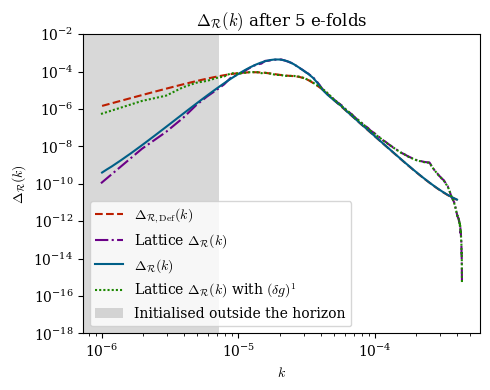

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline
import glob
import matplotlib

matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['font.family'] = 'serif'

Mp = 2.435e18
M_p = 2.435e18
f_star = M_p
omega_star = M_p

myblue = "#005f87"   # MS
myred  = "#bc1e00"   # deformed MS

lattice_normal   = "#6b0087"
lattice_deformed = "#1c8700"

# -------------------------------------------------
# Helpers
# -------------------------------------------------
def read_and_process_file(file_path):
    with open(file_path, 'r') as f:
        lines = f.readlines()
    data = [list(map(float, line.split())) for line in lines]
    return list(zip(*data))

def read_blocks(file_path):
    with open(file_path, 'r') as f:
        blocks = f.read().strip().split("\n\n")
    return [block.strip() for block in blocks]

def read_times(time_file_path):
    with open(time_file_path, 'r') as f:
        times = [float(line.strip()) for line in f.readlines()]
    return times

def process_block(block):
    data = [list(map(float, line.split())) for line in block.split("\n")]
    return list(zip(*data))

def extract_Nf(filename):
    return int(filename.split("Nf=")[-1].split(".txt")[0])

def build_background(path):
    avg_scalar = read_and_process_file(path + 'average_scalar_0.txt')
    avg_sf = read_and_process_file(path + 'average_scale_factor.txt')
    avg_energies = read_and_process_file(path + 'average_energies.txt')
    spectra_blocks = read_blocks(path + 'spectra_scalar_0.txt')
    spectra_times = read_times(path + 'average_spectra_times.txt')

    t = np.array(avg_sf[0])
    a = np.array(avg_sf[1])
    a_t = UnivariateSpline(t, a, s=0)

    Hubble = np.array(avg_sf[3]) * omega_star / M_p
    Hubble_t = UnivariateSpline(t, Hubble, s=0)

    phi = np.array(avg_scalar[1]) * f_star / M_p
    phi_t = UnivariateSpline(t, phi, s=0)

    dphi = np.array(avg_scalar[2]) * f_star * omega_star / M_p**2
    dphi_t = UnivariateSpline(t, dphi, s=0)

    ddphi_t_calc = dphi_t.derivative()

    def epsilon_t(tt):
        return 0.5 * dphi_t(tt)**2 / (Hubble_t(tt)**2)

    def ddphi_t(tt):
        return ddphi_t_calc(tt) * omega_star / M_p

    def eta_t(tt):
        return -ddphi_t(tt) / (Hubble_t(tt) * dphi_t(tt))

    return {
        "a_t": a_t,
        "Hubble_t": Hubble_t,
        "dphi_t": dphi_t,
        "epsilon_t": epsilon_t,
        "eta_t": eta_t,
        "spectra_blocks": spectra_blocks,
        "spectra_times": spectra_times,
    }

def nearest_snapshot_index(spectra_times, a_t, target_Ne):
    current_Nes = np.array([np.log(a_t(tt)) for tt in spectra_times])
    return int(np.abs(current_Nes - target_Ne).argmin())

# -------------------------------------------------
# File locations
# -------------------------------------------------
path_normal = '../ModifiedCLOutput/pbh/'
path_pert = '../CLOutput/pbh/'

files_nonmod = sorted(glob.glob("../Analytics/pbh_CL/PS_modified_Nf=*.txt"))
files_mod    = sorted(glob.glob("../Analytics/pbh_CL/PS_Nf=*.txt"))

Nf_values = sorted(list(set([extract_Nf(f) for f in files_nonmod + files_mod])))

# -------------------------------------------------
# Backgrounds
# -------------------------------------------------
bg_normal = build_background(path_normal)
bg_pert = build_background(path_pert)

# -------------------------------------------------
# Plot
# -------------------------------------------------
target_Ne = 5

plt.figure(figsize=[5, 4])

for file in files_mod:
    data = np.loadtxt(file)
    k = data[:, 0]
    P = data[:, 1]
    Nf = extract_Nf(file)
    if Nf != target_Ne:
        continue
    plt.plot(
        k / Mp, P,
        linestyle='--',
        color=myred,
        label=rf'$\Delta_{{\mathcal{{R}},\mathrm{{Def}}}}(k)$'
    )

# Lattice snapshot at 5 e-folds: normal
idx_normal = nearest_snapshot_index(
    bg_normal["spectra_times"], bg_normal["a_t"], target_Ne
)
block = bg_normal["spectra_blocks"][idx_normal]
x, y1, y2, y3 = process_block(block)

time = bg_normal["spectra_times"][idx_normal]
DeltaR = np.array(y1) * f_star**2 / (2 * bg_normal["epsilon_t"](time) * M_p**2)

k = np.array(x) * omega_star
plt.plot(
    k / M_p, DeltaR,
    linestyle='dashdot',
    color=lattice_normal,
    label=r'Lattice $\Delta_{\mathcal{R}}(k)$'
)

# Analytic / MS curves
for file in files_nonmod:
    data = np.loadtxt(file)
    k = data[:, 0]
    P = data[:, 1]
    Nf = extract_Nf(file)
    if Nf != target_Ne:
        continue
    plt.plot(
        k / Mp, P,
        linestyle='-',
        color=myblue,
        label=rf'$\Delta_{{\mathcal{{R}}}}(k)$'
    )

# Lattice snapshot at 5 e-folds: deformed ($(\delta g)^1$)
idx_def = nearest_snapshot_index(
    bg_pert["spectra_times"], bg_pert["a_t"], target_Ne
)
block = bg_pert["spectra_blocks"][idx_def]
x, y1, y2, y3 = process_block(block)

time = bg_pert["spectra_times"][idx_def]
DeltaR = np.array(y1) * f_star**2 / (2 * bg_pert["epsilon_t"](time) * M_p**2)

k = np.array(x) * omega_star
plt.plot(
    k / M_p, DeltaR,
    linestyle=(0, (1, 1)),
    color=lattice_deformed,
    label=r'Lattice $\Delta_{\mathcal{R}}(k)$ with $(\delta g)^1$'
)

plt.title(r'$\Delta_{\mathcal{R}}(k)$ after 5 e-folds')
plt.xlabel(r'$k$')
plt.ylabel(r'$\Delta_\mathcal{R}(k)$')
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-18, 1e-2)
plt.axvspan(kh_t(0)-1, kh_t(0), facecolor='grey', alpha=.3, label="Initialised outside the horizon")
plt.legend()
plt.tight_layout()
plt.show()